# Implied market returns from the market portfolio

## Introduction

Expected returns for different assets can be estimated implicitly from the **market portfolio** by assuming that the market portfolio is mean-variance efficient and that a covariance matrix for asset returns is known.

Under this approach, the observed market-cap weights are treated as the solution to an equilibrium optimization problem, so the vector of expected excess returns can be backed out from the covariance matrix and the market weights, scaled by a risk-aversion parameter. In effect, rather than forecasting returns directly, we infer the returns that would make the market portfolio optimal for a representative investor. 

This method rests on several strong assumptions: investors are rational and mean-variance optimizing, markets are **informationally efficient** and in **equilibrium**, the market portfolio is an appropriate proxy for aggregate investor holdings, the covariance matrix is correctly estimated, and a single risk-aversion parameter adequately summarizes investor preferences. These assumptions are clearly restrictive, but the approach provides a disciplined and internally consistent starting point. 

In the Black-Litterman model, these implied equilibrium returns form the 'first step': they serve as the neutral prior, which can then be combined with an investor’s own views to produce adjusted expected returns reflecting their active calls. We will cover more on the Black-Litterman model in our last lecture.

## The inputs

Assume that we have $N$ assets. The set of inputs relating to market parameters are:

\begin{array}{ll}
w & \mbox{a vector ($N \times 1$) of equilibrium market weights of the assets} \\
\Sigma & \mbox{covariance matrix ($N \times N$) of the assets} \\
r_f & \mbox{the risk-free rate} \\
\gamma & \mbox{the investor's risk aversion parameter}  \\
\end{array}

Some of these parameters can be inferred from other parameters if they are not explicitly specified. For instance, a very common convention is to set the risk-aversion parameter $\gamma = 2.5$ when computing market-implied equilibrium returns in Black-Litterman-style setups.This value is very often cited as a practical “world average” choice in the Black-Litterman literature and implementations.

That said, in practice many people prefer to calibrate it rather than fix it arbitrarily. Therefore, another common approach is to set $\gamma$ to the market price of risk, which is computed as:

$$\gamma = (\mu_m-r_f)/\sigma^2_m$$

where $\mu_m$ and $\sigma^2_m$ are estimates of the mean and variance of the returns of the market portfolio. Frequently, a broad market index, such as the MSCI ACWI (for equities) or an equivalent of the UBS Global Asset Management Global Securities Markets Index (GSMI) which now retired, is taken as a proxy for the market in order to compute the market price of risk. So 2.5 is the popular rule of thumb, while market risk premium divided by market variance is the more data-driven way to estimate it for a specific market and time period.

## The reverse optimization formula

The **reverse optimization** that infers the implied excess returns vector $\mu_e=(\mu_m-r_f)$ that are implied by the equilibrium weights $w$ is:

$$\mu_e = \gamma\Sigma w$$

**Question:** can you derive the formula above based on the mean-variance equation we saw in the lectures?



## Exercise

The code below calculates market-implied returns following the approach and data in the He and Litterman (1999) paper. See link below:

https://people.duke.edu/~charvey/Teaching/BA453_2004/GS_The_intuition_behind.pdf

The He-Litterman example considers an international asset allocation problem across seven countries. We first input the data from the He-Litterman tables and then write the code needed to perform the reverse optimization to test and validate the implementation.

**Important note**: for simplicity, He and Litterman (1999) use the term “expected return” to mean expected excess return over the one-period risk-free rate (see footnote 1). Accordingly, the data below should be interpreted as excess return series.

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Appendix A of the He-Litterman paper:

countries  = ['AU', 'CA', 'FR', 'DE', 'JP', 'UK', 'US'] 

# Table 1, column 2: volatilities
vols = pd.DataFrame([0.160, 0.203, 0.248, 0.271, 0.210, 0.200, 0.187], index=countries, columns=["Vol"]) 

# Table 1, column 3: market-cap weights
w_m = pd.DataFrame([0.016, 0.022, 0.052, 0.055, 0.116, 0.124, 0.615], index=countries, columns=["CapWeight"])

# Table 2: Correlation Matrix
rho = pd.DataFrame([[1.000, 0.488, 0.478, 0.515, 0.439, 0.512, 0.491],
                    [0.488, 1.000, 0.664, 0.655, 0.310, 0.608, 0.779],
                    [0.478, 0.664, 1.000, 0.861, 0.355, 0.783, 0.668],
                    [0.515, 0.655, 0.861, 1.000, 0.354, 0.777, 0.653],
                    [0.439, 0.310, 0.355, 0.354, 1.000, 0.405, 0.306],
                    [0.512, 0.608, 0.783, 0.777, 0.405, 1.000, 0.652],
                    [0.491, 0.779, 0.668, 0.653, 0.306, 0.652, 1.000]],
                   index=countries, columns=countries)


In [3]:
# Compute the covariance matrix:

sigma_m = vols @ (vols.T) * rho
sigma_m

,AU,CA,FR,DE,JP,UK,US
AU,0.025600,0.015850,0.018967,0.022330,0.014750,0.016384,0.014691
CA,0.015850,0.041209,0.033428,0.036034,0.013215,0.024685,0.029572
FR,0.018967,0.033428,0.061504,0.057866,0.018488,0.038837,0.030979
DE,0.022330,0.036034,0.057866,0.073441,0.020146,0.042113,0.033092
JP,0.014750,0.013215,0.018488,0.020146,0.044100,0.017010,0.012017
UK,0.016384,0.024685,0.038837,0.042113,0.017010,0.040000,0.024385
US,0.014691,0.029572,0.030979,0.033092,0.012017,0.024385,0.034969


In [4]:
# Define implied return function:

def implied_returns(gamma, sigma, w):
    """
    Compute the implied expected returns by reverse engineering
    the weights of the market portfolio.

    Inputs:
    delta: risk aversion coefficient (scalar)
    sigma: variance-covariance matrix (N x N)
    w: portfolio weights (N x 1)

    Returns:
    An N x 1 vector of returns
    """
    
    impl_ret = gamma * (sigma @ w).squeeze()
    impl_ret.name = "Implied Returns"
    
    return impl_ret


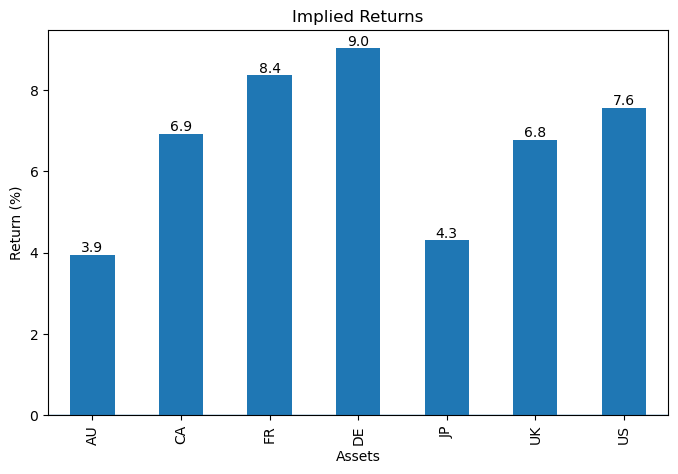

In [5]:
# Compute returns and compare:

ret_m = implied_returns(gamma=2.5, sigma=sigma_m, w=w_m)*100
ret_m.round(1)

import matplotlib.pyplot as plt

ax = ret_m.plot(kind="bar", figsize=(8, 5))
ax.set_title("Implied Returns")
ax.set_xlabel("Assets")
ax.set_ylabel("Return (%)")
ax.axhline(0, linewidth=1)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.1f}", ha="center", va="bottom")
    
plt.show()

The values of the market implied returns match column 4 of Table 1.

### Find mean-variance optimal weights

We can now examine the optimal portfolio weights implied by mean-variance optimization. In particular, what happens if these expected returns are used to construct the optimal maximum Sharpe ratio portfolio?

When there are no constraints on portfolio weights, the **maximum Sharpe ratio (MSR)** portfolio has a simple closed-form solution:

$$ w_{MSR} = \frac{\Sigma^{-1}\mu_e}{\bf{1}^T \Sigma^{-1}\mu_e} $$

where $\mu_e$ is the vector of expected excess returns and $\Sigma$ is the variance-covariance matrix.

This is implemented as follows:



In [6]:
def inverse(d):
    """
    Invert the DataFrame by inverting the underlying matrix.
    """
    return pd.DataFrame(np.linalg.inv(d.values), index=d.columns, columns=d.index)

def w_msr(sigma, mu):
    """
    Optimal (Max Sharpe Ratio) portfolio weights using mean-variance optimization.

    mu is the vector of excess expected returns.
    sigma must be an N x N matrix as a DataFrame and mu a column vector as a Series.
    """
    w = inverse(sigma) @ mu
    w = w / sum(w)
    return w


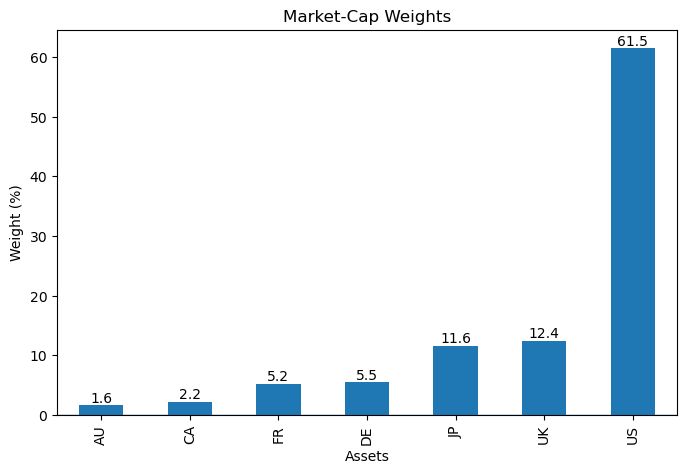

In [7]:
# Compute max Sharpe ratio portfolio:

mc_w = w_msr(sigma=sigma_m, mu=ret_m)*100

ax = mc_w.plot(kind="bar", figsize=(8, 5))
ax.set_title("Market-Cap Weights")
ax.set_xlabel("Assets")
ax.set_ylabel("Weight (%)")
ax.axhline(0, linewidth=1)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.1f}", ha="center", va="bottom")
plt.show()

These weighs exactly match the market-cap weights that we originally used to inform the market implied returns.

## Time for you to try

Now that you have reproduced the results, you should be able to apply the code to an industry/benchmark portfolio:

1) Begin by loading the data, and then experiment with it!

2) What results do you get if you use the mean-variance/CRRA code you used in our previous lecture? Why? How do your results link to the idea of mean-variance being and 'error maximizer'? (See below if you need help).

In [31]:
# Hint: 

from scipy.optimize import minimize

rng = np.random.default_rng(2) # create random number generator with seed 2
n_sims = 100000
sim_rets = rng.multivariate_normal(ret_m/100, sigma_m, size=n_sims) # simulate returns as normally distributed
sim_rets = np.clip(sim_rets, -0.99, None)

def crra_utility(...):
    ...
    ...
    return ...

gamma = #??

n = len(countries)
x0 = np.repeat(1/n, n)
bounds = [(0.0, 1.0)] * n # long only
base_cons = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}] # fully invested

res = minimize(
    lambda w, g=gamma: -crra_utility(w, gamma),
    x0=x0,
    method="SLSQP",
    bounds=bounds,
    constraints=base_cons,
    options={"maxiter": 500})
w = res.x

print((w*100).round(1))

<class 'SyntaxError'>: invalid syntax (<ipython-input-31-84af88f027d7>, line 9)